In [1]:
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import emoji, re, string

import nltk
from nltk.corpus import stopwords
import spacy


from datasets import Dataset


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import evaluate


d:\Arquivos_Acer\Documents\UFC\PrejudicePT-br-main\ambiente_prejudice\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../../Datasets/Telegram_Tratado_Rotulado_Revisado_Final.csv')
df.head()

,text_content_anonymous,preconceito
0,"Sim, eu sou um ""decepcionado""!\n\nEu vejo pess...",0
1,"Em épocas com muitos eventos grandes, altas qu...",0
2,Algumas premissas que ele adotou:\n- Ser de di...,0
3,Apocalipse 22:11. Cristo fez expiação por Seu ...,0
4,:sun_with_face:S:rose:H:cherry_blossom:A:sunfl...,0


In [3]:
df.shape

(3000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text_content_anonymous  3000 non-null   object
 1   preconceito             3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [5]:
mensagens_coluna = 'text_content_anonymous'  
df[mensagens_coluna] = df[mensagens_coluna].astype(str) # garantindo que todos os valores são strings

# Tokenizar mensagens (simples divisão por espaços)
df['num_tokens'] = df[mensagens_coluna].apply(lambda x: len(x.split()))

## Processamento do texto

In [6]:
unicode_emoji = {}
for key, value in emoji.EMOJI_DATA.items():
    try:
        unicode_emoji[key] = value['pt']
    except:
        pass

#emojis and punctuation
emojis_list = list(unicode_emoji)
punct = list(string.punctuation)
emojis_punct = emojis_list + punct

def processEmojisPunctuation(text, remove_punct = True):
    '''
    Put spaces between emojis. Removes punctuation.
    '''
    #get all unique chars
    chars = set(text)
    #for each unique char in text, do:
    for c in chars:
        #remove punctuation
        if remove_punct:
            if c in emojis_list:
                text = text.replace(c, ' ' + c + ' ')
            if c in punct:
                text = text.replace(c, ' ')

        #put spaces between punctuation
        else:
            if c in emojis_punct:
                text = text.replace(c, ' ' + c + ' ')          

    text = text.replace('  ', ' ')
    return text

#stop words removal
stop_words = list(stopwords.words('portuguese'))
new_stopwords = ['aí','pra','vão','vou','onde','lá','aqui',
                 'tá','pode','pois','so','deu','agora','todo',
                 'nao','ja','vc', 'bom', 'ai','kkk','kkkk','ta', 'voce', 'alguem', 'ne', 'pq',
                 'cara','to','mim','la','vcs','tbm', 'tudo']
stop_words = stop_words + new_stopwords
final_stop_words = []
for sw in stop_words:
    sw = ' '+ sw + ' '
    final_stop_words.append(sw)

def removeStopwords(text):
    for sw in final_stop_words:
        text = text.replace(sw,' ')
    text = text.replace('  ',' ')
    return text

#lemmatization
nlp = spacy.load('pt_core_news_sm')
def lemmatization(text):
    doc = nlp(text)
    for token in doc:
        if token.text != token.lemma_:
            text = text.replace(token.text, token.lemma_)
    return text


def domainUrl(text):
    '''
    Substitutes an URL in a text for the domain of this URL
    Input: an string
    Output: the string with the modified URL
    '''    
    if 'http' in text:
        re_url = '[^\s]*https*://[^\s]*'
        matches = re.findall(re_url, text, flags=re.IGNORECASE)
        for m in matches:
            domain = m.split('//')
            domain = domain[1].split('/')[0]
            text = re.sub(re_url, domain, text, 1)
        return text
    else:
        return text 

def preprocess(text):
    text = text.lower().strip()
    text = domainUrl(text)
    text = processEmojisPunctuation(text)
    text = removeStopwords(text)
    text = lemmatization(text)
    return text


In [7]:
# === Renomeando colunas ===
df = df.rename(columns={
    "text_content_anonymous": "text",
    "preconceito": "label"
})
df["label"] = df["label"].astype(int)


In [8]:
df.head()

,text,label,num_tokens
0,"Sim, eu sou um ""decepcionado""!\n\nEu vejo pess...",0,147
1,"Em épocas com muitos eventos grandes, altas qu...",0,167
2,Algumas premissas que ele adotou:\n- Ser de di...,0,150
3,Apocalipse 22:11. Cristo fez expiação por Seu ...,0,163
4,:sun_with_face:S:rose:H:cherry_blossom:A:sunfl...,0,103


In [9]:
# Função de pré-processamento
def preprocess_data(df, experiment):
    if 'processed' in experiment:
        print("Pré-processamento ativado.")
        pro_texts = [preprocess(t) for t in df['text']]
    else:
        print("Sem pré-processamento.")
        pro_texts = [processEmojisPunctuation(t.lower(), remove_punct=False) for t in df['text']]
    return pro_texts


## Modelos Pré treinados - Sem pré processamento

In [10]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="raw")  
df.head()

Sem pré-processamento.


,text,label,num_tokens
0,"sim , eu sou um "" decepcionado "" ! \n\neu vejo...",0,147
1,"em épocas com muitos eventos grandes , altas q...",0,167
2,algumas premissas que ele adotou : \n - ser de...,0,150
3,apocalipse 22 : 11 . cristo fez expiação por ...,0,163
4,: sun _ with _ face : s : rose : h : cherry _...,0,103


No código Hugging Face puro (Trainer) → não há um vocab_size explícito, porque o modelo resolve tudo internamente. O modelo trabalha direto no embedding (768) e na camada de classificação.

### melll-uff/bertweetbr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 720.95 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\3299510.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 1915.54 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\3299510.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:01<00:00, 546.68 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\3299510.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 1919.20 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\3299510.py:55: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


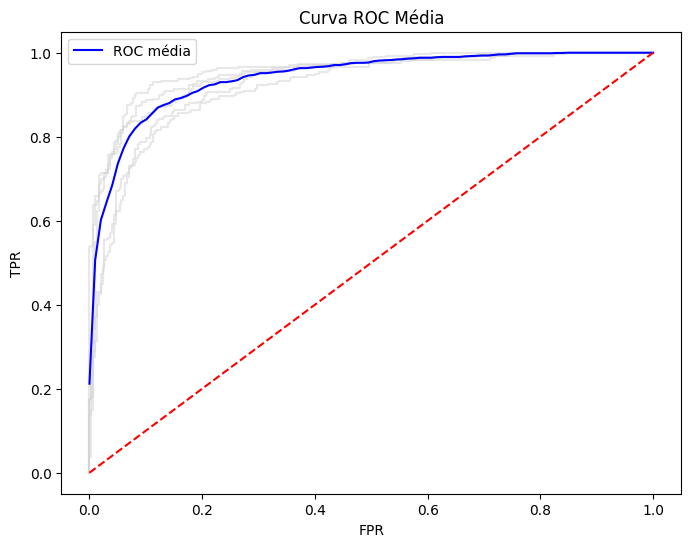

In [11]:

# === Configurações ===
model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
experiments_start_time = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )


    trainer.train()
    # Predições
    preds = trainer.predict(test_dataset)
    
    experiment_time = time.time() - experiments_start_time

    # Predições e métricas
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))


# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_experiment_time_sec": experiment_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_melll_uff_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_melll_uff_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_melll_uff_Sempre_processamento.png", dpi=300)
plt.show()


### FpOliveira/tupi-bert-base-portuguese-cased

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 11539.83 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 12439.30 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 12627.87 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 12329.96 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2379516802.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


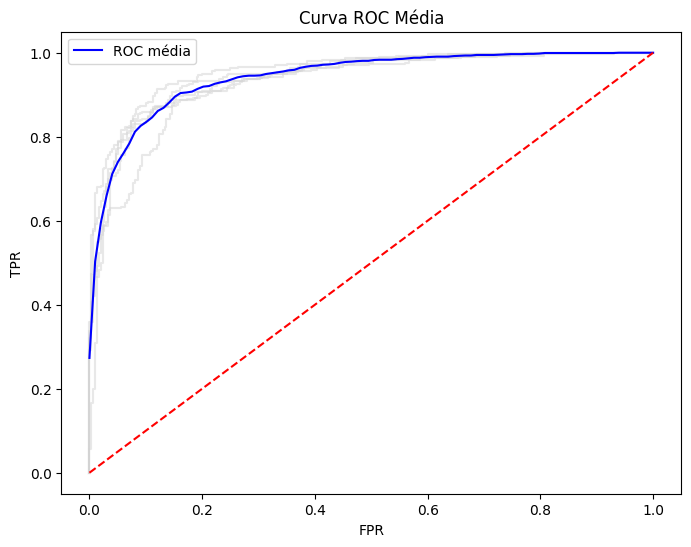

In [ ]:

# === Configurações ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_FpOliveira_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_FpOliveira_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_FpOliveira_Sempre_processamento.png", dpi=300)
plt.show()


### ruanchaves/bert-base-portuguese-cased-hatebr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 17358.73 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 14074.77 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 10296.94 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 12095.06 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\1264454331.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


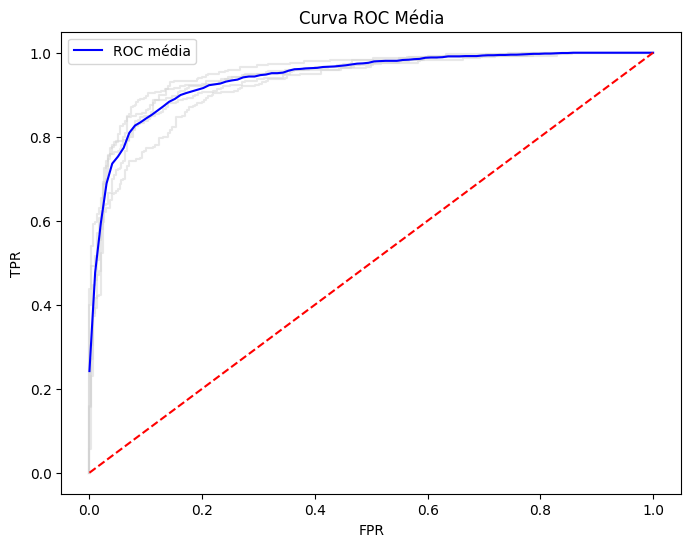

In [13]:

# === Configurações ===
model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_ruanchaves_Sempre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_ruanchaves_Sempre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_ruanchaves_Sempre_processamento.png", dpi=300)
plt.show()


## Modelo pré treinados - Com pré processamento

In [14]:
# === Pré-processamento dinâmico ===
df["text"] = preprocess_data(df, experiment="processed")  
df.head()

Pré-processamento ativado.


,text,label,num_tokens
0,sim decepcionar \n\neu vejo pessoa tentar je...,0,147
1,em época muito evento grande alta quantidade e...,0,167
2,algum premissa adotar \n direita \n ter rede s...,0,150
3,apocalipse 22 11 cristo fazer expiação povo a...,0,163
4,sun with face s rose h cherry blossom sunflo...,0,103


### melll-uff/bertweetbr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 2312.44 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 2611.56 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 2680.18 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 2585.30 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at melll-uff/bertweetbr and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\345591446.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


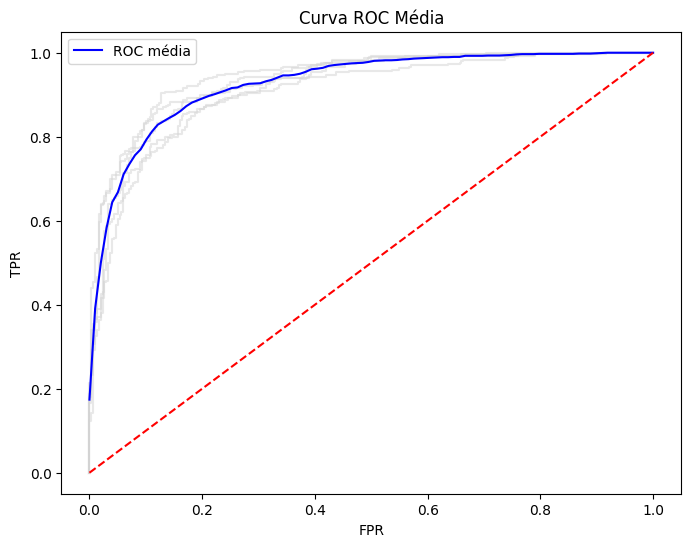

In [15]:

# === Configurações ===
model_name = "melll-uff/bertweetbr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_melll_uff_Compre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_melll_uff_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_melll_uff_Compre_processamento.png", dpi=300)
plt.show()


### FpOliveira/tupi-bert-base-portuguese-cased

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 12723.64 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 10709.04 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 16068.28 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 17444.04 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\283951782.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


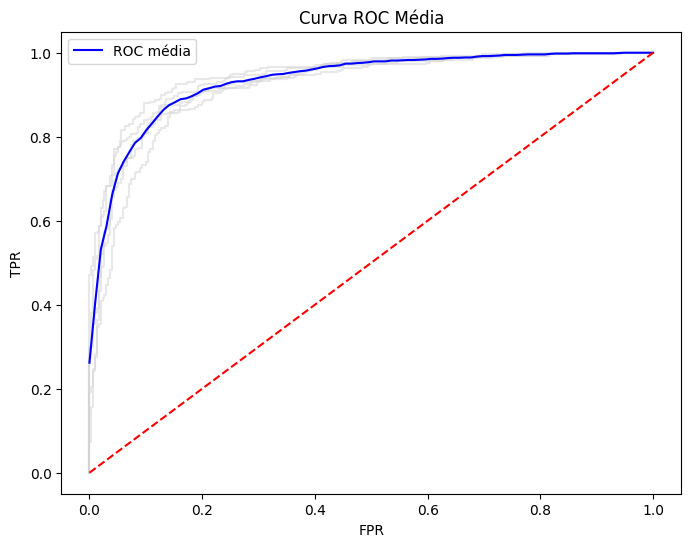

In [16]:

# === Configurações ===
model_name = "FpOliveira/tupi-bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_FpOliveira_Compre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_FpOliveira_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_FpOliveira_Compre_processamento.png", dpi=300)
plt.show()


### ruanchaves/bert-base-portuguese-cased-hatebr

=== Fold 1 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 12383.35 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 2 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 15288.34 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Map: 100%|██████████| 600/600 [00:00<00:00, 16930.04 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


=== Fold 5 ===


Map: 100%|██████████| 600/600 [00:00<00:00, 16014.29 examples/s]
C:\Users\Melissa Felipe\AppData\Local\Temp\ipykernel_30452\2768694142.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


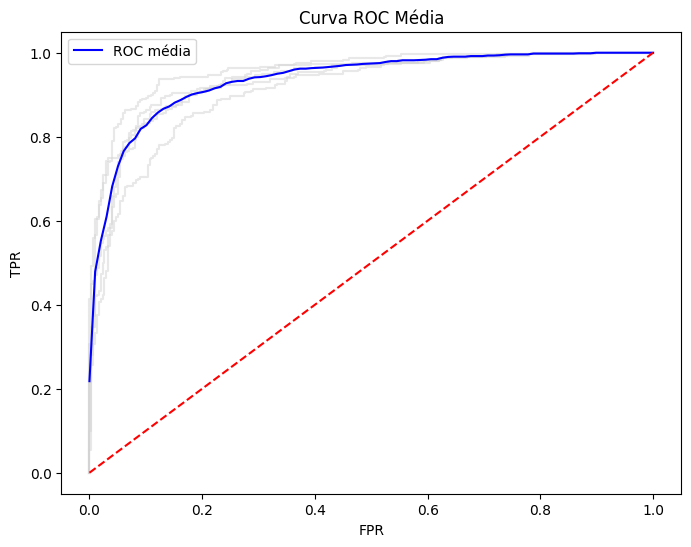

In [17]:

# === Configurações ===
model_name = "ruanchaves/bert-base-portuguese-cased-hatebr"
tokenizer = AutoTokenizer.from_pretrained(model_name)


num_labels = df["label"].nunique()
id2label = {i: f"Classe {i}" for i in range(num_labels)}
label2id = {v: k for k, v in id2label.items()}


# Função de tokenização
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# === Cross Validation ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics_results = []
roc_curves = []
start_total = time.time()

for fold, (train_idx, test_idx) in enumerate(skf.split(df["text"], df["label"]), start=1):
    print(f"=== Fold {fold} ===")

    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Converte para Dataset do HF
    from datasets import Dataset
    train_dataset = Dataset.from_pandas(train_df).map(tokenize_fn, batched=True)
    test_dataset = Dataset.from_pandas(test_df).map(tokenize_fn, batched=True)

    # Carrega modelo novo a cada fold
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, 
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        use_safetensors=True,
        ignore_mismatched_sizes=True  # o modelo foi treinado com 12 classes, mas estou ignorando o 
                                        # erro de incompatibilidade de forma na camada final e recriar a Linear layer com num_labels=3. 
    )

    # Configuração de treinamento
    training_args = TrainingArguments(
        #output_dir=f"./results_fold_{fold}",
        #evaluation_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        #logging_dir=f"./logs_fold_{fold}",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        tokenizer=tokenizer
    )

    start_fold = time.time()
    trainer.train()
    elapsed_fold = time.time() - start_fold

    # Predições
    preds = trainer.predict(test_dataset)
    y_true = np.array(test_df["label"])
    y_pred = np.argmax(preds.predictions, axis=1)
    y_prob = preds.predictions[:, 1]

    # Métricas
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    metrics_results.append({
        "fold": fold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "time_sec": elapsed_fold
    })

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_curves.append((fpr, tpr))

total_time = time.time() - start_total

# === Estatísticas ===
metrics_df = pd.DataFrame(metrics_results)
summary = {
    "accuracy_avg": metrics_df["accuracy"].mean(),
    "accuracy_std": metrics_df["accuracy"].std(),
    "precision_avg": metrics_df["precision"].mean(),
    "precision_std": metrics_df["precision"].std(),
    "recall_avg": metrics_df["recall"].mean(),
    "recall_std": metrics_df["recall"].std(),
    "f1_avg": metrics_df["f1"].mean(),
    "f1_std": metrics_df["f1"].std(),
    "roc_auc_avg": metrics_df["roc_auc"].mean(),
    "roc_auc_std": metrics_df["roc_auc"].std(),
    "total_time_sec": total_time
}

# Salvar CSV
metrics_df.to_csv("./resultados/resultados_folds_ruanchaves_Commpre_processamento.csv", index=False)
pd.DataFrame([summary]).to_csv("./resultados/resultados_resumo_ruanchaves_Compre_processamento.csv", index=False)

# === Plot Curva ROC média ===
plt.figure(figsize=(8, 6))
for fpr, tpr in roc_curves:
    plt.plot(fpr, tpr, color="lightgray", alpha=0.5)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.zeros_like(mean_fpr)
for fpr, tpr in roc_curves:
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
mean_tpr /= len(roc_curves)

plt.plot(mean_fpr, mean_tpr, color="blue", label="ROC média")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC Média")
plt.legend()
plt.savefig("./resultados/roc_media_ruanchaves_Compre_processamento.png", dpi=300)
plt.show()
